<a href="https://colab.research.google.com/github/vinaekalaylani/object-coin/blob/main/object_coin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import graycomatrix, graycoprops
from google.colab import files

Upload an image file:


Saving coin.jpg to coin.jpg


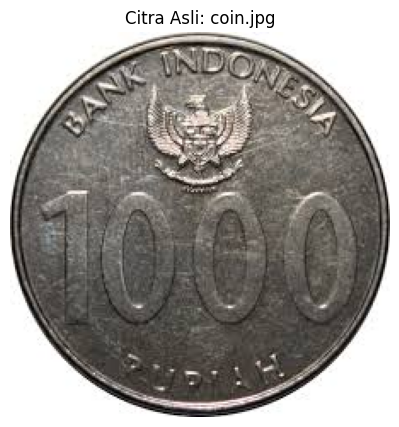

In [ ]:
print("Upload an image file:")
uploaded = files.upload()
filename = next(iter(uploaded))

img = cv2.imread(filename)
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(5,5))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title(f"Citra Asli: {filename}")
plt.axis('off')
plt.show()

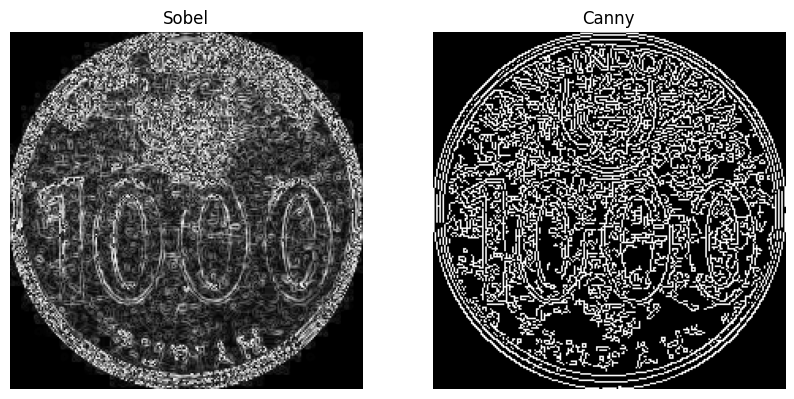

In [ ]:
# Edge detection (Sobel & Canny)
# Sobel
sobelx = cv2.Sobel(img_gray, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(img_gray, cv2.CV_64F, 0, 1, ksize=3)
sobel = cv2.magnitude(sobelx, sobely)
sobel = np.uint8(sobel)

# Canny
canny = cv2.Canny(img_gray, 50, 150)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(sobel, cmap='gray')
ax[0].set_title("Sobel")
ax[1].imshow(canny, cmap='gray')
ax[1].set_title("Canny")
for a in ax: a.axis('off')
plt.show()

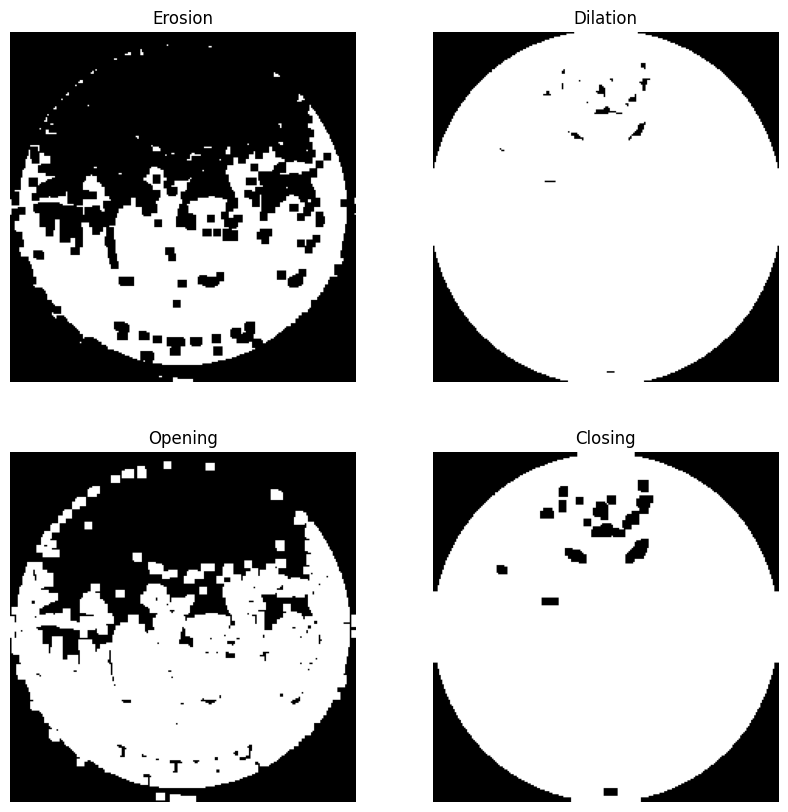

In [ ]:
# Morphological operations
_, thresh = cv2.threshold(img_gray, 127, 255, cv2.THRESH_BINARY_INV)
kernel = np.ones((5,5), np.uint8)

erosi = cv2.erode(thresh, kernel, iterations=1)
dilasi = cv2.dilate(thresh, kernel, iterations=1)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)
closing = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)

# visualization
fig, ax = plt.subplots(2, 2, figsize=(10, 10))
ax[0, 0].imshow(erosi, cmap='gray')
ax[0, 0].set_title("Erosion")
ax[0, 1].imshow(dilasi, cmap='gray')
ax[0, 1].set_title("Dilation")
ax[1, 0].imshow(opening, cmap='gray')
ax[1, 0].set_title("Opening")
ax[1, 1].imshow(closing, cmap='gray')
ax[1, 1].set_title("Closing")
for row in ax:
    for a in row: a.axis('off')
plt.show()

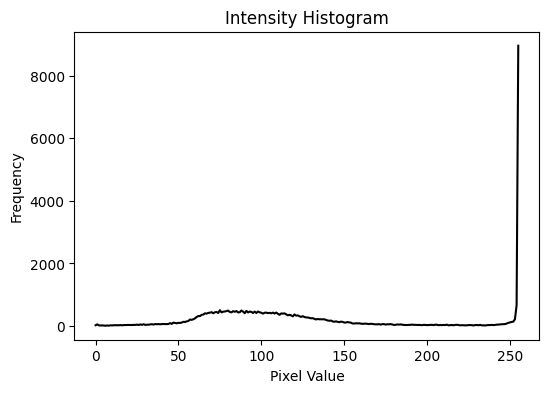


FEATURE VALUE SUMMARY TABLE
Intensity feature (Mean) : 134.70
GLCM contrast            : 698.5315
GLCM homogeneity         : 0.2502
Contour area             : 39197.50 pixels
Contour perimeter        : 750.48 pixels


In [ ]:
# Feature extraction
# Intensity histogram
hist = cv2.calcHist([img_gray], [0], None, [256], [0,256])
mean_intensity = np.mean(img_gray)

plt.figure(figsize=(6,4))
plt.plot(hist, color='black')
plt.title("Intensity Histogram")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()

# GLCM texture (Contrast & Homogeneity)
glcm = graycomatrix(img_gray, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)
contrast = graycoprops(glcm, 'contrast')[0, 0]
homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]

# Contour shape (Area & Perimeter)
contours, _ = cv2.findContours(closing, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
if contours:
    c = max(contours, key=cv2.contourArea)
    area = cv2.contourArea(c)
    perimeter = cv2.arcLength(c, True)
else:
    area, perimeter = 0, 0

print("\n" + "="*40)
print("FEATURE VALUE SUMMARY TABLE")
print("="*40)
print(f"Intensity feature (Mean) : {mean_intensity:.2f}")
print(f"GLCM contrast            : {contrast:.4f}")
print(f"GLCM homogeneity         : {homogeneity:.4f}")
print(f"Contour area             : {area:.2f} pixels")
print(f"Contour perimeter        : {perimeter:.2f} pixels")
print("="*40)